# Gemini 2.X - Multi-tool with the Multimodal Live API

In this notebook you will learn how to use tools, including charting tools, Google Search and code execution in the [Gemini 2](https://ai.google.dev/gemini-api/docs/models/gemini-v2) Multimodal Live API. For an overview of new capabilities refer to the [Gemini 2 docs](https://ai.google.dev/gemini-api/docs/models/gemini-v2).

If you aren't looking for code, and just want to try multimedia streaming use [Live API in Google AI Studio](https://aistudio.google.com/app/live).


## Setup

### Install the Google GenAI SDK

Install the Google GenAI SDK from [npm](https://www.npmjs.com/package/@google/genai). 

```bash
$ npm install @google/genai
```

### Setup your API key

You can [create](https://aistudio.google.com/app/apikey) your API key using Google AI Studio with a single click.

Remember to treat your API key like a password. Don't accidentally save it in a notebook or source file you later commit to GitHub. In this notebook we will be storing the API key in a `.env` file. You can also set it as an environment variable or use a secret manager. 

Here's how to set it up in a `.env` file:

```bash
$ touch .env
$ echo "GEMINI_API_KEY=<YOUR_API_KEY>" >> .env
```

:::{.callout-tip}

Another option is to set the API key as an environment variable. You can do this in your terminal with the following command:

```bash
$ export GEMINI_API_KEY="<YOUR_API_KEY>"
```
:::

### Load the API key

To load the API key from the `.env` file, we will use the `dotenv` package. This package loads environment variables from a `.env` file into `process.env`. 

```bash
$ npm install dotenv
```

Then, we can load the API key in our code:


In [147]:
const dotenv = require("dotenv") as typeof import("dotenv");

dotenv.config({
  path: "../.env",
});

const GEMINI_API_KEY = process.env.GEMINI_API_KEY ?? "";
if (!GEMINI_API_KEY) {
  throw new Error("GEMINI_API_KEY is not set in the environment variables");
}
console.log("GEMINI_API_KEY is set in the environment variables");

const GEOAPI_KEY = process.env.GEOAPI_KEY ?? "";
if (!GEOAPI_KEY) {
  throw new Error("GEOAPI_KEY is not set in the environment variables");
}
console.log("GEOAPI_KEY is set in the environment variables");


GEMINI_API_KEY is set in the environment variables
GEOAPI_KEY is set in the environment variables


:::{.callout-note}
In our particular case the `.env` is is one directory up from the notebook, hence we need to use `../` to go up one directory. If the `.env` file is in the same directory as the notebook, you can omit it altogether. 

```
│
├── .env
└── examples
    └── LiveAPI_plotting_and_mapping.ipynb
```
:::


### Initialize SDK Client

With the new SDK, now you only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.


In [2]:
const google = require("@google/genai") as typeof import("@google/genai");

const ai = new google.GoogleGenAI({ apiKey: GEMINI_API_KEY });


### Select a model

Now select the model you want to use in this guide, either by selecting one in the list or writing it down. Keep in mind that some models, like the 2.5 ones are thinking models and thus take slightly more time to respond (cf. [thinking notebook](../quickstarts/Get_started_thinking.ipynb) for more details and in particular learn how to switch the thiking off).


In [10]:
const tslab = require("tslab") as typeof import("tslab");

const LIVE_MODEL_ID = "gemini-2.0-flash-live-001";


## Utilities

You’re going to use the Live API’s audio output, the easiest way hear it in Colab is to write the PCM data out as a WAV file:


In [5]:
const fs = require("fs") as typeof import("fs");
const path = require("path") as typeof import("path");
const wave = require("wavefile") as typeof import("wavefile");

function saveAudioToFile(audioData: Int16Array, filePath: string) {
  fs.mkdirSync(path.dirname(filePath), { recursive: true });
  const wav = new wave.WaveFile();
  wav.fromScratch(1, 24000, "16", audioData);
  fs.writeFileSync(filePath, wav.toBuffer());
  console.debug(`Audio saved to ${filePath}`);
}


In [ ]:
import { FunctionResponse, LiveServerContent, LiveServerToolCall, Session } from "@google/genai";

function handleServerContent(content: LiveServerContent) {
  if (content.modelTurn) {
    for (const turn of content.modelTurn.parts ?? []) {
      if (turn.executableCode) {
        tslab.display.markdown(`\`\`\`python\n${turn.executableCode.code}\n\`\`\``);
      }
      if (turn.codeExecutionResult) {
        tslab.display.markdown(`\`\`\`\n${turn.codeExecutionResult.output}\n\`\`\``);
      }
    }
  }
  if (content.groundingMetadata) {
    tslab.display.html(content.groundingMetadata.searchEntryPoint?.renderedContent ?? "");
  }
}

function handleToolCall(
  session: Session,
  toolCall: LiveServerToolCall,
  callableMap: Record<string, (...args: unknown[]) => unknown>
) {
  console.log("Tool call received:", JSON.stringify(toolCall, null, 2));
  const responses: FunctionResponse[] = [];
  for (const fc of toolCall.functionCalls ?? []) {
    let result = { response: "ok" };
    if (fc.name in callableMap) {
      try {
        result = (callableMap[fc.name] as (...args: unknown[]) => unknown)(fc.arguments);
        console.log(`Tool ${fc.name} executed successfully with result:`, result);
      } catch (error) {
        console.error(`Error executing tool ${fc.name}:`, error);
        result = { response: `Error executing tool ${fc.name}: ${error}` };
      }
    } else {
      console.warn(`No callable function found for tool ${fc.name}`);
    }
    responses.push({
      id: fc.id,
      name: fc.name,
      response: result,
    });
  }
  console.log("Tool call responses:", JSON.stringify(responses, null, 2));
  session.sendToolResponse({
    functionResponses: responses,
  });
}


In [ ]:
import { Modality, Tool, LiveServerMessage, Session } from "@google/genai";

class GenAISession {
  private session: Session | null = null;
  private modality: Modality;
  private tools: Tool[];
  private systemInstructions: string;
  private audioData: number[] = [];
  private textAccumulator = "";
  private completed = false;

  private callableMap: Record<string, (...args: unknown[]) => unknown> = {};

  constructor(modality: Modality = Modality.TEXT, tools: Tool[] = [], systemInstructions = "") {
    this.modality = modality;
    this.tools = tools;
    this.systemInstructions = systemInstructions;
  }

  setCallableMap(callableMap: Record<string, (...args: unknown[]) => unknown>) {
    this.callableMap = callableMap;
  }

  async open() {
    this.session = await ai.live.connect({
      model: LIVE_MODEL_ID,
      callbacks: {
        onopen: () => {
          console.log("Connection opened");
        },
        onclose: () => {
          console.log("Connection closed");
        },
        onerror: (error) => {
          console.error("Error:", error.message);
        },
        onmessage: (message) => {
          this.handleMessage(message);
        },
      },
      config: {
        tools: this.tools,
        responseModalities: [this.modality],
        systemInstruction: this.systemInstructions,
      },
    });
  }

  private handleMessage(message: LiveServerMessage) {
    if (message.text) {
      this.textAccumulator += message.text;
      return;
    }

    const flushText = message.serverContent ?? message.toolCall;
    if (flushText && this.textAccumulator) {
      tslab.display.markdown(this.textAccumulator);
      this.textAccumulator = "";
    }

    if (message.data) {
      const audioBuffer = Buffer.from(message.data, "base64");
      const audio = new Int16Array(
        audioBuffer.buffer,
        audioBuffer.byteOffset,
        audioBuffer.length / Int16Array.BYTES_PER_ELEMENT
      );
      this.audioData.push(...audio);
    }

    if (message.serverContent) {
      handleServerContent(message.serverContent);
      if (message.serverContent.turnComplete) {
        this.completed = true;
      }
    }

    if (message.toolCall) {
      handleToolCall(this.session, message.toolCall, this.callableMap);
      this.completed = true;
    }
  }

  async sendPrompt(prompt: string): Promise<void> {
    this.completed = false;
    this.textAccumulator = "";

    this.session.sendClientContent({
      turns: [prompt],
      turnComplete: true,
    });

    // eslint-disable-next-line @typescript-eslint/no-unnecessary-condition
    while (!this.completed) {
      await new Promise((resolve) => setTimeout(resolve, 100));
    }

    if (this.audioData.length > 0) {
      const audioFileName = `audio-${Date.now()}.wav`;
      const savePath = path.join("../assets/live_audio", audioFileName);
      saveAudioToFile(new Int16Array(this.audioData), savePath);
      console.log(`Audio saved to ${audioFileName}`);
      tslab.display.html(
        `<audio controls><source src="${audioFileName}" type="audio/wav">Your browser does not support the audio element.</audio>`
      );
    }
  }

  close() {
    this.session?.close();
  }
}


## Use the API

### One-turn example

Now, let's see how all the pieces you've defined fit together in a simple example. You'll send a single prompt to the API and observe the response.

This example uses the following function to send a prompt to the API and print the response:

- `handleServerContent`: This function handles responses from the server, printing the content with appropriate formatting.
- `handleToolCall`: This function handles tool calls, printing the tool name and arguments and returning a response.

All of the above is bought together in the `GenAISession` class that manages the session, tools, and server communication.

Note that you can change the modality from `AUDIO` to `TEXT` and adjust the prompt.


In [23]:
// temporarily make console.warn a no-op to avoid warnings in the output (non-text part in GenerateContentResponse caused by accessing .text)
// https://github.com/googleapis/js-genai/blob/d82aba244bdb804b063ef8a983b2916c00b901d2/src/types.ts#L2005
// copy the original console.warn function to restore it later
const warn_fn = console.warn;
// eslint-disable-next-line @typescript-eslint/no-empty-function, no-empty-function
console.warn = function () {};

async function oneTurnExample() {
  const session = new GenAISession(google.Modality.TEXT, [{ googleSearch: {} }, { codeExecution: {} }]);
  await session.open();
  await session.sendPrompt(
    "Please find the last 5 Denis Villeneuve movies and look up their runtimes and the year published."
  );
  session.close();
}

await oneTurnExample();

// restore console.warn later
// console.warn = warn_fn;


Connection opened


```python
concise_search("Denis Villeneuve filmography", max_num_results=5)

```

```
Looking up information on Google Search.

```

Based on the search results, the last 5 Denis Villeneuve movies are:

1.  Dune: Part Two (2024)
2.  Dune (2021)
3.  Blade Runner 2049 (2017)
4.  Arrival (2016)
5.  Sicario (2015)

Now I will search for the runtimes of these movies.


```python
concise_search("Dune: Part Two runtime", max_num_results=2)
concise_search("Dune (2021) runtime", max_num_results=2)
concise_search("Blade Runner 2049 runtime", max_num_results=2)
concise_search("Arrival (2016) runtime", max_num_results=2)
concise_search("Sicario (2015) runtime", max_num_results=2)

```

...

```
Looking up information on Google Search.

```

```
Looking up information on Google Search.

```

Here is the information on the last 5 Denis Villeneuve movies, including their release year and runtime:

*   **Sicario (2015):** 2 hours 1 minute (121 minutes)
*   **Arrival (2016):** 1 hour 56 minutes (116 minutes or 118 minutes depending on the source)
*   **Blade Runner 2049 (2017):** 2 hours 44 minutes (164 minutes)
*   **Dune (2021):** 2 hours 35 minutes (155 minutes)
*   **Dune: Part Two (2024):** 2 hours 45 minutes (165 minutes or 166 minutes, with seconds specified as 165 minutes and 37 seconds)

Sicario (2015) runtime

Connection closed


### Complex multi-tool example

Now define additional tools. Add a tool for charting by defining a schema (in altair_fns), a function to execute (render_altair) and connect the two using the tool_calls mapping.

The charting tool used here is Vega-Altair, a "declarative statistical visualization library for Python". Altair supports chart persistance using JSON, which you will expose as a tool so that the Gemini model can produce a chart.

The helper code defined earlier will run as soon as it can, but audio takes some time to play so you may see output from later turns displayed before the audio has played.


In [ ]:
import { FunctionDeclaration } from "@google/genai";

interface AltairSpec {
  data?: {
    values?: unknown[];
    name?: string;
  };
  datasets?: Record<string, unknown[]>;
  encoding?: {
    x?: {
      field: string;
      title?: string;
    };
    y?: {
      field: string;
      title?: string;
    };
    tooltip?: { field: string }[];
  };
  mark?: string | { type: string; point?: boolean };
  title?: string | { text: string };
}

const altairFn: FunctionDeclaration = {
  name: "render_altair",
  description: "Displays an Altair chart in JSON format.",
  parameters: {
    type: google.Type.OBJECT,
    properties: {
      altair_json: {
        type: google.Type.STRING,
        description: "JSON STRING representation of the Altair chart to render. Must be a string, not a json object",
      },
    },
    required: ["altair_json"],
  },
};

// eslint-disable-next-line complexity
function altairToPlotlyHTML({
  altairStr,
  divId = `plotly-vis-${Math.random().toString(36).substring(2, 15)}`,
  width = 800,
  height = 600,
}: {
  altairStr: string;
  divId?: string;
  width?: number;
  height?: number;
}): Record<string, unknown> {
  let altairSpec: AltairSpec;
  try {
    altairSpec = JSON.parse(altairStr) as AltairSpec;
  } catch (err) {
    return { error: "Invalid JSON format." };
  }

  // eslint-disable-next-line @typescript-eslint/no-unnecessary-condition
  if (!altairSpec || typeof altairSpec !== "object") {
    return { error: "Invalid Altair spec format. Must be a valid JSON object." };
  }

  // Resolve data
  let dataValues: unknown[] = [];
  if (altairSpec.data?.values) {
    dataValues = altairSpec.data.values;
  } else if (altairSpec.data?.name && altairSpec.datasets?.[altairSpec.data.name]) {
    dataValues = altairSpec.datasets[altairSpec.data.name];
  } else {
    return { error: "No data values found in Altair spec." };
  }

  const xEncoding = altairSpec.encoding?.x;
  const yEncoding = altairSpec.encoding?.y;
  if (!xEncoding || !yEncoding) {
    return { error: "x or y encoding not found in Altair spec." };
  }

  const xField = xEncoding.field;
  const yField = yEncoding.field;

  // Tooltip fields (optional)
  const tooltipFields = altairSpec.encoding?.tooltip?.map((t) => t.field) ?? [];

  // Resolve mark type
  const mark = typeof altairSpec.mark === "object" ? altairSpec.mark.type : altairSpec.mark;
  const hasPoints = typeof altairSpec.mark === "object" && altairSpec.mark.point;
  const mode = mark === "line" ? (hasPoints ? "lines+markers" : "lines") : "markers";

  const trace = {
    x: dataValues.map((d) => d[xField] as number | string),
    y: dataValues.map((d) => d[yField] as number | string),
    mode,
    type: "scatter",
    text:
      tooltipFields.length > 0
        ? dataValues.map((d) => tooltipFields.map((f) => `${f}: ${d[f]}`).join("<br>"))
        : undefined,
    hoverinfo: tooltipFields.length ? "text" : "x+y",
  };

  const layout = {
    title: {
      text:
        typeof altairSpec.title === "string" ? altairSpec.title : (altairSpec.title?.text ?? "Converted Altair Chart"),
    },
    xaxis: {
      title: { text: xEncoding.title ?? xField },
    },
    yaxis: {
      title: { text: yEncoding.title ?? yField },
    },
    height,
    width,
  };

  const html = `
    <div id="${divId}" style="width: 100%; height: ${height}px;"></div>
    <script src="https://cdn.jsdelivr.net/npm/plotly.js-dist@latest/plotly.min.js"></script>
    <script>
      Plotly.newPlot('${divId}', [${JSON.stringify(trace)}], ${JSON.stringify(layout)});
    </script>
  `;
  tslab.display.html(html);
  return { response: "ok" };
}


In [58]:
async function multiTool() {
  const session = new GenAISession(google.Modality.TEXT, [
    { googleSearch: {} },
    { codeExecution: {} },
    { functionDeclarations: [altairFn] },
  ]);
  session.setCallableMap({
    render_altair: altairToPlotlyHTML,
  });
  await session.open();
  await session.sendPrompt("Please find the last 5 Denis Villeneuve movies and find their runtimes.");
  await session.sendPrompt("Can you write some code to work out which has the longest and shortest runtimes?");
  await session.sendPrompt(
    "Now can you plot them in a line chart showing the year on the x-axis and runtime on the y-axis?"
  );
  session.close();
}

await multiTool();


Connection opened


```python
concise_search("Denis Villeneuve filmography", max_num_results=3)

```

```
Looking up information on Google Search.

```

Based on the search results, the last 5 Denis Villeneuve movies are:

1.  Dune: Part Two (2024)
2.  Dune (2021)
3.  Blade Runner 2049 (2017)
4.  Arrival (2016)
5.  Sicario (2015)

Now I'll search for the runtimes of these movies.


```python
concise_search("Dune: Part Two (2024) runtime", max_num_results=1)
concise_search("Dune (2021) runtime", max_num_results=1)
concise_search("Blade Runner 2049 (2017) runtime", max_num_results=1)
concise_search("Arrival (2016) runtime", max_num_results=1)
concise_search("Sicario (2015) runtime", max_num_results=1)

```

...

I encountered an error when rendering the chart due to a potential issue with the `true` keyword in the Altair JSON. I will correct the json.


```python
import json
chart_json = {
  "$schema": "https://vega.github.io/schema/vega-lite/v4.17.0.json",
  "config": {
    "view": {
      "continuousHeight": 300,
      "continuousWidth": 400
    }
  },
  "data": {
    "name": "data-42b1a7374cbab7106c877130c780e821"
  },
  "datasets": {
    "data-42b1a7374cbab7106c877130c780e821": [
      {
        "Movie": "Dune: Part Two (2024)",
        "Runtime": 166,
        "Year": 2024
      },
      {
        "Movie": "Dune (2021)",
        "Runtime": 155,
        "Year": 2021
      },
      {
        "Movie": "Blade Runner 2049 (2017)",
        "Runtime": 163,
        "Year": 2017
      },
      {
        "Movie": "Arrival (2016)",
        "Runtime": 116,
        "Year": 2016
      },
      {
        "Movie": "Sicario (2015)",
        "Runtime": 121,
        "Year": 2015
      }
    ]
  },
  "encoding": {
    "tooltip": [
      {
        "field": "Movie",
        "type": "nominal"
      },
      {
        "field": "Runtime",
        "type": "quantitative"
      },
      {
        "field": "Year",
        "type": "quantitative"
      }
    ],
    "x": {
      "field": "Year",
      "title": "Year",
      "type": "ordinal"
    },
    "y": {
      "field": "Runtime",
      "title": "Runtime (minutes)",
      "type": "quantitative"
    }
  },
  "mark": {
    "point": True,
    "type": "line"
  },
  "title": "Denis Villeneuve Movie Runtimes"
}
default_api.render_altair(altair_json=json.dumps(chart_json))

```

Tool call received: {
  "functionCalls": [
    {
      "id": "function-call-13821247486491036755",
      "args": {
        "altair_json": "{\"$schema\": \"https://vega.github.io/schema/vega-lite/v4.17.0.json\", \"config\": {\"view\": {\"continuousHeight\": 300, \"continuousWidth\": 400}}, \"data\": {\"name\": \"data-42b1a7374cbab7106c877130c780e821\"}, \"datasets\": {\"data-42b1a7374cbab7106c877130c780e821\": [{\"Movie\": \"Dune: Part Two (2024)\", \"Runtime\": 166, \"Year\": 2024}, {\"Movie\": \"Dune (2021)\", \"Runtime\": 155, \"Year\": 2021}, {\"Movie\": \"Blade Runner 2049 (2017)\", \"Runtime\": 163, \"Year\": 2017}, {\"Movie\": \"Arrival (2016)\", \"Runtime\": 116, \"Year\": 2016}, {\"Movie\": \"Sicario (2015)\", \"Runtime\": 121, \"Year\": 2015}]}, \"encoding\": {\"tooltip\": [{\"field\": \"Movie\", \"type\": \"nominal\"}, {\"field\": \"Runtime\", \"type\": \"quantitative\"}, {\"field\": \"Year\", \"type\": \"quantitative\"}], \"x\": {\"field\": \"Year\", \"title\": \"Year\", \"t

Tool render_altair executed successfully with result: { response: 'ok' }
Tool call responses: [
  {
    "id": "function-call-13821247486491036755",
    "name": "render_altair",
    "response": {
      "response": "ok"
    }
  }
]


Connection closed


### Maps example

For this example you will use the Geoapify Maps Static API to draw on a map during the conversation. You'll need to make sure your API key is enabled for the Geoapify Maps Static API. 

Add the key in your secrets repository, or add it in the code directly (`GEOAPI_KEY = '...'`, not recommended).


The following cell is hidden by default, but needs te be run. It comtains the function schema for the `draw_map` function, including some documentation on how to draw markers with the Google Maps API.

Note that the model needs to produce a fairly complex set of parameters in order to call `draw_map`, including defining a center-point for the map, an integer zoom level and custom marker styles and locations.


In [140]:
import { FunctionDeclaration } from "@google/genai";

const mapFn: FunctionDeclaration = {
  name: "draw_map",
  description: "Render a Google Maps static map using the specified parameters. No information is returned.",
  parameters: {
    type: google.Type.OBJECT,
    properties: {
      center: {
        type: google.Type.STRING,
        description: "Location to center the map. It has to be a lat,lng pair (e.g. 40.714728,-73.998672).",
      },
      zoom: {
        type: google.Type.NUMBER,
        description:
          "Google Maps zoom level. 1 is the world, 20 is zoomed in to building level. Integer only. Level 11 shows about a 15km radius. Level 9 is about 30km radius.",
      },
      path: {
        type: google.Type.STRING,
        description: `The path parameter defines a set of one or more locations connected by a path to overlay on the map image. The path parameter takes set of value assignments (path descriptors) of the following format:

path=pathStyles|pathLocation1|pathLocation2|... etc.

Note that both path points are separated from each other using the pipe character (|). Because both style information and point information is delimited via the pipe character, style information must appear first in any path descriptor. Once the Maps Static API server encounters a location in the path descriptor, all other path parameters are assumed to be locations as well.

Path styles
The set of path style descriptors is a series of value assignments separated by the pipe (|) character. This style descriptor defines the visual attributes to use when displaying the path. These style descriptors contain the following key/value assignments:

weight: (optional) specifies the thickness of the path in pixels. If no weight parameter is set, the path will appear in its default thickness (5 pixels).
color: (optional) specifies a color either as a 24-bit (example: color=0xFFFFCC) or 32-bit hexadecimal value (example: color=0xFFFFCCFF), or from the set {black, brown, green, purple, yellow, blue, gray, orange, red, white} only use hex format of the colors even if they are in the set.

When a 32-bit hex value is specified, the last two characters specify the 8-bit alpha transparency value. This value varies between 00 (completely transparent) and FF (completely opaque). Note that transparencies are supported in paths, though they are not supported for markers.

fillcolor: (optional) indicates both that the path marks off a polygonal area and specifies the fill color to use as an overlay within that area. The set of locations following need not be a "closed" loop; the Maps Static API server will automatically join the first and last points. Note, however, that any stroke on the exterior of the filled area will not be closed unless you specifically provide the same beginning and end location.
geodesic: (optional) indicates that the requested path should be interpreted as a geodesic line that follows the curvature of the earth. When false, the path is rendered as a straight line in screen space. Defaults to false.
Some example path definitions:

Thin blue line, 50% opacity: path=color:0x0000ff80|weight:1
Solid red line: path=color:0xff0000ff|weight:5
Solid thick white line: path=color:0xffffffff|weight:10
These path styles are optional. If default attributes are desired, you may skip defining the path attributes; in that case, the path descriptor's first "argument" will consist instead of the first declared point (location).

Path points
In order to draw a path, the path parameter must also be passed two or more points. The Maps Static API will then connect the path along those points, in the specified order. Each pathPoint is denoted in the pathDescriptor separated by the | (pipe) character.
`,
      },
      markers: {
        type: google.Type.ARRAY,
        items: {
          type: google.Type.STRING,
        },
        description: `The markers parameter defines a set of one or more markers (map pins) at a set of locations. Each marker defined within a single markers declaration must exhibit the same visual style; if you wish to display markers with different styles, you will need to supply multiple markers parameters with separate style information.

The markers parameter takes set of value assignments (marker descriptors) of the following format:

markers=markerStyles|markerLocation1| markerLocation2|... etc.

The set of markerStyles is declared at the beginning of the markers declaration and consists of zero or more style descriptors separated by the pipe character (|), followed by a set of one or more locations also separated by the pipe character (|).

Because both style information and location information is delimited via the pipe character, style information must appear first in any marker descriptor. Once the Maps Static API server encounters a location in the marker descriptor, all other marker parameters are assumed to be locations as well.

Marker styles
The set of marker style descriptors is a series of value assignments separated by the pipe (|) character. This style descriptor defines the visual attributes to use when displaying the markers within this marker descriptor. These style descriptors contain the following key/value assignments:

size: (optional) specifies the size of marker from the set {tiny, mid, small}. If no size parameter is set, the marker will appear in its default (normal) size.
color: (optional) specifies a 24-bit color (example: color=0xFFFFCC) or a predefined color from the set {black, brown, green, purple, yellow, blue, gray, orange, red, white} only use hex format of the colors even if they are in the set.

Note that transparencies (specified using 32-bit hex color values) are not supported in markers, though they are supported for paths.

label: (optional) specifies a single uppercase alphanumeric character from the set {A-Z, 0-9}. (The requirement for uppercase characters is new to this version of the API.) Note that default and mid sized markers are the only markers capable of displaying an alphanumeric-character parameter. tiny and small markers are not capable of displaying an alphanumeric-character.

Note: Location must be specified as a lat,lng pair (e.g. 40.714728,-73.998672). The Maps Static API server will not accept any other location format.
`,
      },
    },
    required: ["center", "zoom"],
  },
};


Now define the `draw_map` function and add `googleSearch` as a tool to use for this conversation. This will allow the model to look up restaurants that might be popular.


In [ ]:
interface MarkerData {
  lat: number;
  lng: number;
  size?: number;
  color?: string;
  label?: string;
}

function parseMarkerString(markerStr: string): MarkerData | null {
  const parts = markerStr.split("|");
  let lat: number | undefined, lng: number | undefined;
  const result: MarkerData = { lat: 0, lng: 0 };

  parts.forEach((part) => {
    const [key, value] = part.split(":");
    // eslint-disable-next-line @typescript-eslint/no-unnecessary-condition
    const trimmedKey = key?.trim().toLowerCase();
    // eslint-disable-next-line @typescript-eslint/no-unnecessary-condition
    const trimmedValue = value?.trim();

    switch (trimmedKey) {
      case "size":
        result.size = { tiny: 12, small: 24, mid: 36, default: 48 }[trimmedValue] ?? 48;
        break;
      case "color":
        // Normalize color format: 0xRRGGBB → #RRGGBB
        if (/^0x[0-9a-fA-F]{6}$/.test(trimmedValue)) {
          result.color = `#${trimmedValue.slice(2)}`;
        } else if (/^#[0-9a-fA-F]{6}$/.test(trimmedValue)) {
          result.color = trimmedValue;
        } else {
          result.color = trimmedValue; // Allow named colors or other formats
        }
        break;
      case "label":
        if (/^[A-Za-z0-9]{1,3}$/.test(trimmedValue)) {
          result.label = trimmedValue;
        }
        break;
      default:
        // eslint-disable-next-line no-case-declarations
        const coords = part.split(",").map((v) => parseFloat(v.trim()));
        if (coords.length === 2 && coords.every((v) => !isNaN(v))) {
          lat = coords[0];
          lng = coords[1];
        }
        break;
    }
  });

  if (typeof lat !== "number" || typeof lng !== "number") {
    console.warn("Invalid or missing coordinates in marker:", markerStr);
    return null;
  }

  result.lat = lat;
  result.lng = lng;
  return result;
}

function generateGeoapifyUrl(
  lat: number,
  lng: number,
  zoom: number, // unused now, but kept for signature
  path: string, // path support removed
  markers: string[] // ["color:<hexOrName>|<label>|<lat>,<lng>", ...]
): string {
  const baseUrl = "https://maps.geoapify.com/v1/staticmap";
  const params = new URLSearchParams({
    style: "osm-bright",
    width: "800",
    height: "600",
    format: "png",
    apiKey: GEOAPI_KEY,
  });

  const lats: number[] = [];
  const lngs: number[] = [];

  markers.forEach((m) => {
    const markerData = parseMarkerString(m);
    console.debug(`Parsed marker data: ${JSON.stringify(markerData)}`);
    const parts = [
      `lonlat:${markerData.lng},${markerData.lat}`,
      `type:awesome`,
      `color:${markerData.color ?? "#000000"}`,
      `size:${markerData.size ?? "48"}`,
      `icon:map-pin`,
      `contentcolor:#ffffff`,
    ];
    if (markerData.label) parts.push(`text:${markerData.label}`);

    params.append("marker", parts.join(";"));
  });

  params.append("marker", `lonlat:${lng},${lat};type:awesome;color:#000000;size:48;icon:map-pin;contentcolor:#ffffff`);

  if (lats.length && lngs.length) {
    const minLat = Math.min(...lats);
    const maxLat = Math.max(...lats);
    const minLng = Math.min(...lngs);
    const maxLng = Math.max(...lngs);
    params.set("bbox", `${minLng},${minLat},${maxLng},${maxLat}`);
  }
  return `${baseUrl}?${params.toString()}`;
}

function drawMap({
  center,
  zoom,
  path = "",
  markers = [],
}: {
  center: string;
  zoom: number;
  path?: string;
  markers?: string[];
}): Record<string, unknown> {
  const [lat, lng] = center.split(",").map((s) => parseFloat(s.trim()));
  if (isNaN(lat) || isNaN(lng)) {
    return { error: "Invalid center coordinates. Must be in the format 'lat,lng'." };
  }
  void fetch(generateGeoapifyUrl(lat, lng, zoom, path, markers))
    .then(async (response) => {
      if (!response.ok) {
        throw new Error(`HTTP error! status: ${response.status}`);
      }
      tslab.display.png(new Uint8Array(await response.arrayBuffer()));
    })
    .catch((error: unknown) => {
      console.error("Error fetching map image:", error);
      tslab.display.markdown(`**Error fetching map image:** ${error instanceof Error ? error.message : String(error)}`);
    });
  return { response: "ok" };
}


Connection opened


```python
concise_search("trending restaurants Sydney", max_num_results=5)

```

```
Looking up information on Google Search.

```

Based on the search results, here are three trending restaurants in Sydney that I can mark on a map:

1.  **Nomad** (Surry Hills)
2.  **Quay** (The Rocks - near Sydney Opera House)
3.  **Bennelong** (Sydney Opera House)



```python
print(default_api.draw_map(center="-33.865143,151.209900", zoom=13, markers=["color:red|-33.8806,151.2133|Nomad", "color:blue|-33.8587,151.2140|Quay", "color:green|-33.8567,151.2153|Bennelong"]))

```

trending restaurants Sydney

Tool call received: {
  "functionCalls": [
    {
      "id": "function-call-10553651478507360710",
      "args": {
        "zoom": 13,
        "markers": [
          "color:red|-33.8806,151.2133|Nomad",
          "color:blue|-33.8587,151.2140|Quay",
          "color:green|-33.8567,151.2153|Bennelong"
        ],
        "center": "-33.865143,151.209900"
      },
      "name": "draw_map"
    }
  ]
}
Parsed marker data: {"lat":-33.8806,"lng":151.2133,"color":"red"}
Parsed marker data: {"lat":-33.8587,"lng":151.214,"color":"blue"}
Parsed marker data: {"lat":-33.8567,"lng":151.2153,"color":"green"}
Tool draw_map executed successfully with result: { response: 'ok' }
Tool call responses: [
  {
    "id": "function-call-10553651478507360710",
    "name": "draw_map",
    "response": {
      "response": "ok"
    }
  }
]


```
{'response': 'ok'}

```

I have marked Nomad (red), Quay (blue), and Bennelong (green) on a map centered around Sydney.


Connection closed


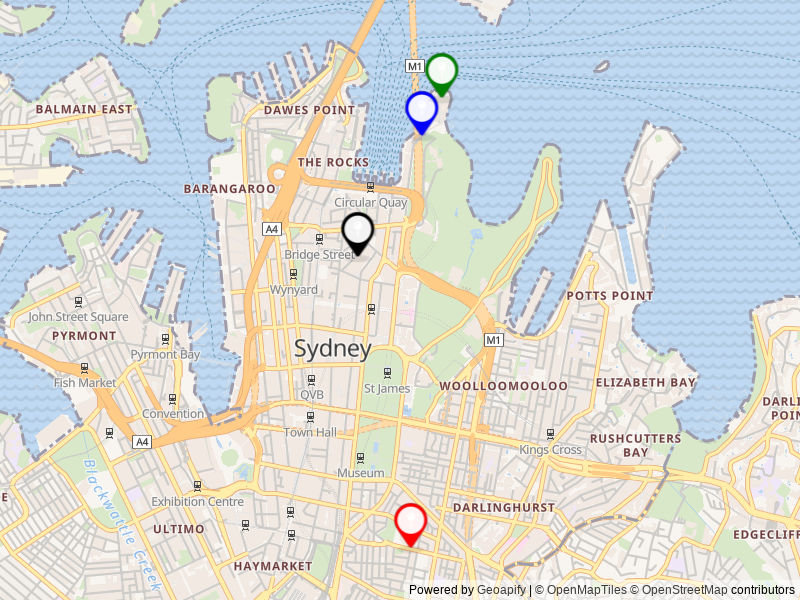

In [ ]:
async function mapExample() {
  const session = new GenAISession(google.Modality.TEXT, [{ googleSearch: {} }, { functionDeclarations: [mapFn] }]);
  session.setCallableMap({
    draw_map: drawMap,
  });
  await session.open();
  await session.sendPrompt("Please look up and mark 3 Sydney restaurants that are currently trending on a map.");
  await session.sendPrompt(
    "Now write some code to randomly pick one to eat at tonight and zoom in to that one on the map."
  );
  session.close();
}

await mapExample();


### Maps with Code execution

In this example, you will use the Google Maps tools defined before, and you'll challenge the model to generate a color gradient and uses it to visually represent data on a map. This task requires code execution, so it is also included as a tool.

Specifically, you will ask the model to plot the capital cities in Australia, and apply a gradient between two colors in a circular direction around the country using Google Maps markers.


Connection opened


Okay, I will plot markers on every capital city in Australia using a gradient between Orange and Green. Here's the plan:

1. **Identify the capital cities and their coordinates:** I'll use search queries to find the capital cities of each Australian state and territory, as well as their latitude and longitude.
2. **Assign colors:** I'll assign colors to the markers, creating a gradient from orange to green. Since there are 8 capital cities, I will generate 8 hex color codes, starting with orange and transitioning to green.
3. **Create marker strings:** I'll construct the marker strings for each capital city, including the color and coordinates.
4. **Call the draw_map function:** I'll call the `draw_map` function with the appropriate center, zoom level, and marker strings. I'll center the map on Australia and use a reasonable zoom level.

Now let's execute the plan.

**Step 1: Identify the capital cities and their coordinates**


```python
concise_search("latitude longitude Canberra", max_num_results=1)
concise_search("latitude longitude Sydney", max_num_results=1)
concise_search("latitude longitude Melbourne", max_num_results=1)
concise_search("latitude longitude Brisbane", max_num_results=1)
concise_search("latitude longitude Perth", max_num_results=1)
concise_search("latitude longitude Adelaide", max_num_results=1)
concise_search("latitude longitude Hobart", max_num_results=1)
concise_search("latitude longitude Darwin", max_num_results=1)

```

```
Looking up information on Google Search.

```

```
Looking up information on Google Search.

```

...

**Step 4: Call the `draw_map` function**

Finally, I'll call the `draw_map` function with the center of Australia and a zoom level that shows the whole continent. I'll use -25, 135 as the center and a zoom level of 4.


```python
center = "-25,135"
zoom = 4
markers = ['color:#ffa500|-35.28,149.13', 'color:#dab100|-33.87,151.21', 'color:#b6be00|-37.81,144.96', 'color:#91cb00|-27.47,153.02', 'color:#6dd800|-31.95,115.86', 'color:#48e500|-34.92,138.6', 'color:#24f200|-42.88,147.32', 'color:#00ff00|-12.46,130.84']
default_api.draw_map(center=center, zoom=zoom, markers=markers)

```

Tool call received: {
  "functionCalls": [
    {
      "id": "function-call-310939628431261825",
      "args": {
        "zoom": 4,
        "center": "-25,135",
        "markers": [
          "color:#ffa500|-35.28,149.13",
          "color:#dab100|-33.87,151.21",
          "color:#b6be00|-37.81,144.96",
          "color:#91cb00|-27.47,153.02",
          "color:#6dd800|-31.95,115.86",
          "color:#48e500|-34.92,138.6",
          "color:#24f200|-42.88,147.32",
          "color:#00ff00|-12.46,130.84"
        ]
      },
      "name": "draw_map"
    }
  ]
}
Parsed marker data: {"lat":-35.28,"lng":149.13,"color":"#ffa500"}
Parsed marker data: {"lat":-33.87,"lng":151.21,"color":"#dab100"}
Parsed marker data: {"lat":-37.81,"lng":144.96,"color":"#b6be00"}
Parsed marker data: {"lat":-27.47,"lng":153.02,"color":"#91cb00"}
Parsed marker data: {"lat":-31.95,"lng":115.86,"color":"#6dd800"}
Parsed marker data: {"lat":-34.92,"lng":138.6,"color":"#48e500"}
Parsed marker data: {"lat":-42.88,"lng":1

I have plotted the capital cities of Australia with a gradient from orange to green.


Connection closed


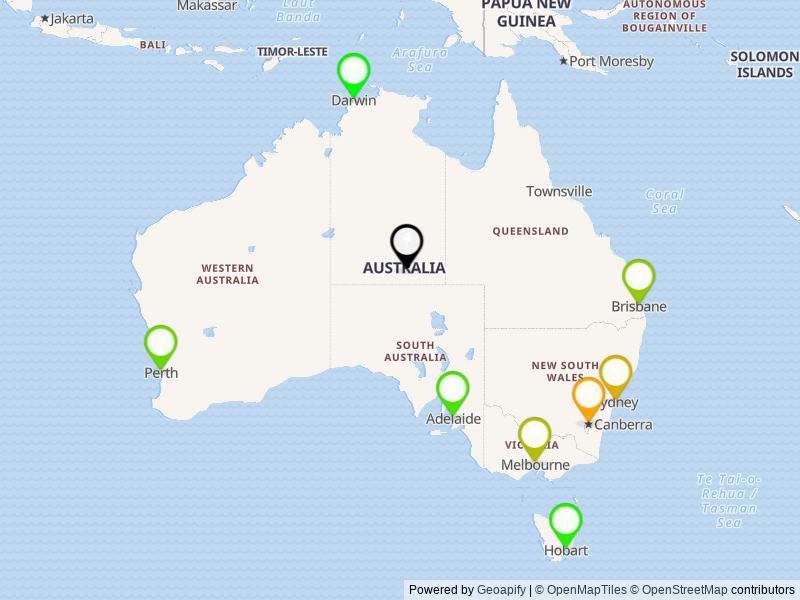

In [ ]:
async function mapWithCodeExecution() {
  const session = new GenAISession(google.Modality.TEXT, [
    { googleSearch: {} },
    { codeExecution: {} },
    { functionDeclarations: [mapFn] },
  ]);
  session.setCallableMap({
    draw_map: drawMap,
  });
  await session.open();
  await session.sendPrompt(
    "Plot markers on every capital city in Australia using a gradient between Orange and Green. Plan out your steps first, then follow the plan."
  );
  await session.sendPrompt(
    "Awesome! Can you ensure the gradient is applied smoothly in a circular direction around the country?"
  );
  session.close();
}

await mapWithCodeExecution();


Performance in this example depends on your feedback to get the output perfect. This example showed the first 2 steps of a hypothetical conversation, but you could keep iterating with the model until the results are what you need.


## Next steps

This guide shows more intermedite use of the Multimodal Live API over Websockets.

- To try multimodal streaming, use [Live API in Google AI Studio](https://aistudio.google.com/app/live) - no code required.
- Check out the [Live API starter using the JS SDK](../quickstarts/Get_started_LiveAPI.ipynb).
- Try some other [grounding](Search_grounding_for_research_report.ipynb) examples.
- Try the [Tool use in the live API tutorial](../quickstarts/Get_started_LiveAPI_tools.ipynb) for a walkthrough of Gemini 2.0's new tool use capabilities.

Or just check the other Gemini capabilities illustrated in the Cookbook examples.
